In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from datetime import datetime

BASE      = Path(r'G:\financial_kg')
PROC      = BASE / 'data' / 'processed'
STATS_DIR = BASE / 'data' / 'stats'

# MLflow
mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.set_experiment('FinancialKG_Phase2_Cleaning')
run = mlflow.start_run(run_name=f'cleaning_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
RUN_ID = run.info.run_id

print('Imports OK')
print(f'Run ID: {RUN_ID}')

# Load corpus
corpus_df = pd.read_parquet(PROC / 'corpus_combined.parquet')
print(f'Loaded: {len(corpus_df):,} texts')

2026/05/06 18:04:24 INFO mlflow.tracking.fluent: Experiment with name 'FinancialKG_Phase2_Cleaning' does not exist. Creating a new experiment.


Imports OK
Run ID: ad81b143c3f54f658c6c371ae5ae0f05
Loaded: 89,626 texts


In [2]:
# ── Cleaning functions per source ─────────────────────────

def clean_sec(text: str) -> str:
    """Remove EDGAR navigation artifacts from SEC filings."""
    # Remove EDGAR boilerplate
    noise_patterns = [
        r'EDGAR Filing Documents.*?Javascript',
        r'This page uses Javascript.*?turned off',
        r'Table of Contents',
        r'\bEX-\d+\b',
        r'Filed pursuant to.*?Exchange Act',
        r'Commission file number.*?\d+',
        r'^\s*\d+\s*$',           # lone page numbers
        r'F-\d+',                  # financial statement page refs
    ]
    for pat in noise_patterns:
        text = re.sub(pat, ' ', text, flags=re.IGNORECASE)
    return text


def clean_twitter(text: str) -> str:
    """Clean Twitter financial text."""
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'\$[A-Z]+', r'\g<0>', text)   # keep ticker symbols
    text = re.sub(r'@\w+', '', text)             # remove mentions
    text = re.sub(r'#\w+', '', text)             # remove hashtags
    return text


def clean_general(text: str) -> str:
    """General cleaning for all sources."""
    # Fix encoding
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text)
    # Remove lines that are just numbers/symbols
    text = re.sub(r'^\W+$', '', text, flags=re.MULTILINE)
    return text.strip()


def clean_text(row) -> str:
    text   = str(row['text'])
    source = str(row['source'])

    if source == 'sec_edgar':
        text = clean_sec(text)
    elif source == 'twitter_finance':
        text = clean_twitter(text)

    text = clean_general(text)
    return text


# ── Apply cleaning ────────────────────────────────────────
print('Cleaning corpus...')
corpus_df['text_clean'] = corpus_df.apply(clean_text, axis=1)

# ── Filter quality ────────────────────────────────────────
before = len(corpus_df)

# Remove too short after cleaning
corpus_df = corpus_df[corpus_df['text_clean'].str.split().str.len() >= 5]

# Remove texts that are mostly numbers/symbols
corpus_df = corpus_df[
    corpus_df['text_clean'].str.replace(r'[^a-zA-Z\s]','',regex=True)
    .str.split().str.len() >= 4
]

corpus_df['word_count'] = corpus_df['text_clean'].str.split().str.len()
after = len(corpus_df)

print(f'Before cleaning : {before:,}')
print(f'After cleaning  : {after:,}')
print(f'Removed         : {before - after:,}')
print(f'Avg words       : {corpus_df["word_count"].mean():.1f}')

mlflow.log_metrics({
    'clean_before' : before,
    'clean_after'  : after,
    'clean_removed': before - after,
    'clean_avg_words': round(corpus_df['word_count'].mean(), 1),
})

# Show before/after SEC example
print('\nSEC BEFORE:')
sec_sample = corpus_df[corpus_df['source']=='sec_edgar']['text'].iloc[0]
print(f'  {sec_sample[:200]}')
print('\nSEC AFTER:')
sec_clean = corpus_df[corpus_df['source']=='sec_edgar']['text_clean'].iloc[0]
print(f'  {sec_clean[:200]}')

Cleaning corpus...
Before cleaning : 89,626
After cleaning  : 89,405
Removed         : 221
Avg words       : 71.1

SEC BEFORE:
  EDGAR Filing Documents for 0000320193-25-000079 This page uses Javascript. Your browser either doesn't support Javascript or you have it turned off. To see this page as it is meant to appear please us

SEC AFTER:
  . Your browser either doesn't support Javascript or you have it turned off. To see this page as it is meant to appear please use a Javascript enabled browser. SEC.gov EDGAR Latest Filings Filings sear


SEC chunks before : 947
SEC chunks after  : 932
SEC chunks removed: 15

Final clean corpus:
  Total texts : 89,390
  Total words : 6,352,363
  Avg words   : 71.1

Per source:
source
finance_alpaca              56580
fingpt_sentiment            17041
twitter_finance              9172
financial_classification     4521
sec_edgar                     932
auditor_sentiment             468
flare_ner                     407
fiqa_2018                     195
yahoo_finance                  42
seeking_alpha                  23
marketwatch                     9


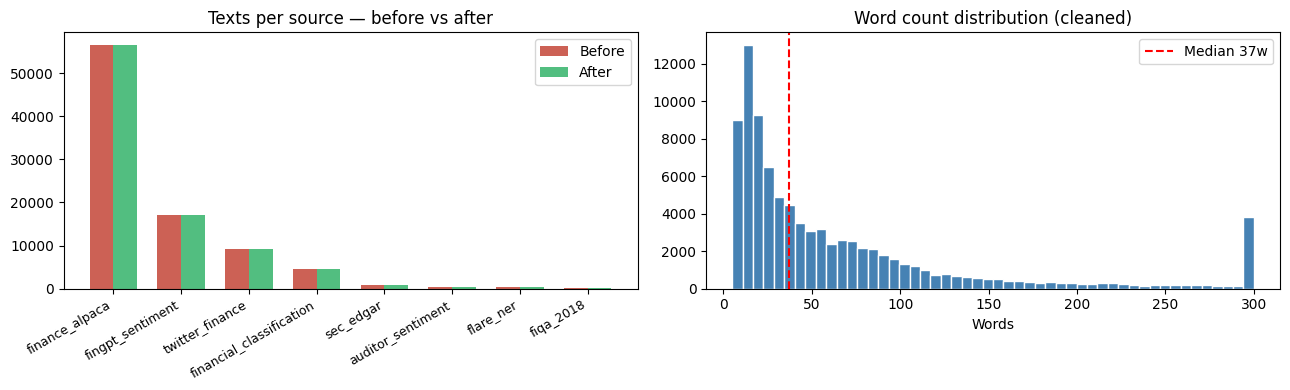


Saved to G:\financial_kg\data\processed/corpus_clean.parquet


In [3]:
# ── Filter out bad SEC chunks ─────────────────────────────
SEC_NOISE = [
    'javascript', 'edgar', 'browser', 'sec.gov',
    'filing documents', 'filings search', 'enabled browser',
]

def is_good_sec(text: str) -> bool:
    text_lower = text.lower()
    noise_count = sum(1 for n in SEC_NOISE if n in text_lower)
    return noise_count <= 1

before_sec = len(corpus_df[corpus_df['source'] == 'sec_edgar'])

# Keep only good SEC chunks
sec_mask = corpus_df['source'] == 'sec_edgar'
good_sec  = corpus_df[sec_mask].apply(lambda r: is_good_sec(r['text_clean']), axis=1)
drop_idx  = corpus_df[sec_mask][~good_sec].index
corpus_df = corpus_df.drop(drop_idx).reset_index(drop=True)

after_sec = len(corpus_df[corpus_df['source'] == 'sec_edgar'])

print(f'SEC chunks before : {before_sec}')
print(f'SEC chunks after  : {after_sec}')
print(f'SEC chunks removed: {before_sec - after_sec}')

# ── Final clean corpus ────────────────────────────────────
# Replace text with cleaned version
corpus_df['text'] = corpus_df['text_clean']
corpus_df = corpus_df.drop(columns=['text_clean'])
corpus_df['word_count'] = corpus_df['text'].str.split().str.len()

print(f'\nFinal clean corpus:')
print(f'  Total texts : {len(corpus_df):,}')
print(f'  Total words : {corpus_df["word_count"].sum():,}')
print(f'  Avg words   : {corpus_df["word_count"].mean():.1f}')
print(f'\nPer source:')
print(corpus_df['source'].value_counts().to_string())

# ── Before vs after chart ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

before_counts = pd.Series({
    'finance_alpaca': 56659, 'fingpt_sentiment': 17049,
    'twitter_finance': 9297, 'financial_classification': 4521,
    'sec_edgar': before_sec, 'auditor_sentiment': 468,
    'flare_ner': 407, 'fiqa_2018': 204,
})
after_counts = corpus_df['source'].value_counts()

x      = np.arange(len(before_counts))
width  = 0.35
labels = list(before_counts.index)

axes[0].bar(x - width/2, [before_counts.get(l,0) for l in labels],
            width, label='Before', color='#c0392b', alpha=0.8)
axes[0].bar(x + width/2, [after_counts.get(l,0) for l in labels],
            width, label='After', color='#27ae60', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Texts per source — before vs after')
axes[0].legend()

axes[1].hist(corpus_df['word_count'].clip(upper=300), bins=50,
             color='steelblue', edgecolor='white')
axes[1].axvline(corpus_df['word_count'].median(), color='red',
                linestyle='--', label=f'Median {corpus_df["word_count"].median():.0f}w')
axes[1].set_title('Word count distribution (cleaned)')
axes[1].set_xlabel('Words')
axes[1].legend()

plt.tight_layout()
chart = str(STATS_DIR / 'cleaned_corpus.png')
plt.savefig(chart, dpi=120, bbox_inches='tight')
plt.show()
mlflow.log_artifact(chart, artifact_path='charts')

# Save
corpus_df.to_parquet(PROC / 'corpus_clean.parquet', index=False)
mlflow.log_metrics({
    'final_texts' : len(corpus_df),
    'final_words' : int(corpus_df['word_count'].sum()),
})
print(f'\nSaved to {PROC}/corpus_clean.parquet')

In [4]:
# ── Final quality report ──────────────────────────────────
import json

quality_report = {
    'mlflow_run_id'  : RUN_ID,
    'phase'          : 2,
    'total_texts'    : len(corpus_df),
    'total_words'    : int(corpus_df['word_count'].sum()),
    'avg_words'      : round(corpus_df['word_count'].mean(), 1),
    'median_words'   : round(corpus_df['word_count'].median(), 1),
    'sources'        : corpus_df['source'].value_counts().to_dict(),
    'duplicates'     : 0,
    'nulls'          : 0,
}

report_path = STATS_DIR / 'quality_report_phase2.json'
with open(report_path, 'w') as f:
    json.dump(quality_report, f, indent=2)

mlflow.log_artifact(str(report_path), artifact_path='reports')

# Close run
mlflow.end_run()

print('='*50)
print('  PHASE 2 COMPLETE — DATA CLEANING')
print('='*50)
print(f'  Total texts  : {len(corpus_df):,}')
print(f'  Total words  : {corpus_df["word_count"].sum():,}')
print(f'  Sources      : {corpus_df["source"].nunique()}')
print(f'  Saved to     : {PROC}/corpus_clean.parquet')
print(f'  MLflow run   : {RUN_ID}')
print(f'  View at      : http://127.0.0.1:5000')
print()
print('  NEXT: Phase 3 — NER + Relation Extraction model')

  PHASE 2 COMPLETE — DATA CLEANING
  Total texts  : 89,390
  Total words  : 6,352,363
  Sources      : 11
  Saved to     : G:\financial_kg\data\processed/corpus_clean.parquet
  MLflow run   : ad81b143c3f54f658c6c371ae5ae0f05
  View at      : http://127.0.0.1:5000

  NEXT: Phase 3 — NER + Relation Extraction model
